In [8]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from source.dataset import CIFAR10Pair, get_train_transform, get_test_transform
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from tqdm import tqdm
import matplotlib.pyplot as plt
from source.model import SimCLRModel
from source.loss import NTXentLoss
import json
import torch.nn as nn
import torchvision.transforms as transforms



Lets take our dataset images and run random data augmentations on 3 different dataset images to verify:

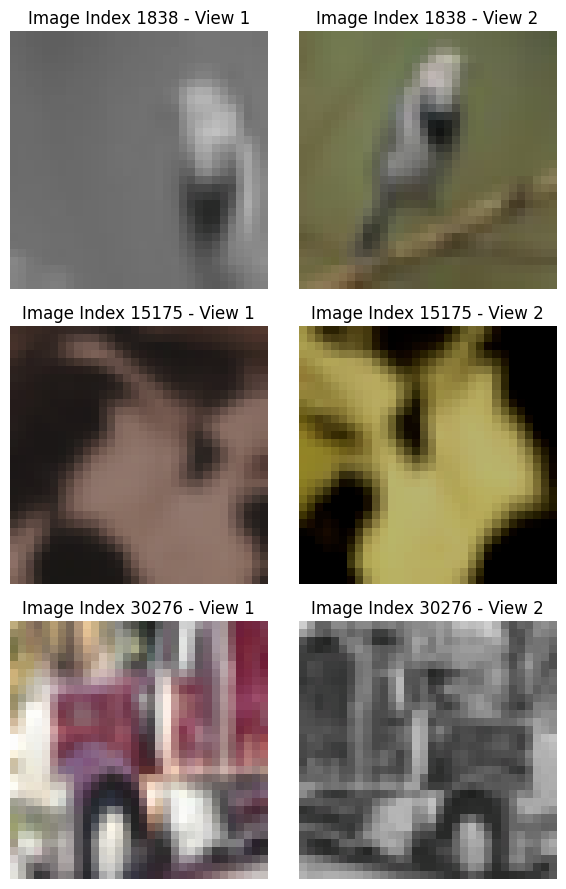

In [2]:
train_dataset = CIFAR10Pair(
    root='./data', 
    train=True, 
    transform=get_train_transform(), 
    download=False
)
def imshow(img):
    # Standard CIFAR-10 mean and std used in dataset.py
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    # Denormalize: image = image * std + mean
    img = img * std + mean
    # Clip values to be between 0 and 1 so matplotlib renders correctly
    img = torch.clamp(img, 0, 1)
    # Convert from PyTorch tensor (Channels, Height, Width) 
    # to Numpy array (Height, Width, Channels)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
# Plot 3 random pairs
num_pairs = 3
plt.figure(figsize=(6, 9))
for i in range(num_pairs):
    # Pick a random image index
    idx = torch.randint(len(train_dataset), size=(1,)).item()
    
    # Grab the two augmented views from your dataset class
    pos_1, pos_2, target = train_dataset[idx]
    
    # Plot View 1 (x_i)
    plt.subplot(num_pairs, 2, 2*i + 1)
    imshow(pos_1)
    plt.title(f"Image Index {idx} - View 1")
    
    # Plot View 2 (x_j)
    plt.subplot(num_pairs, 2, 2*i + 2)
    imshow(pos_2)
    plt.title(f"Image Index {idx} - View 2")
plt.tight_layout()
plt.show()

After completing necessary functions on my model and loss function in their .py files, let's define and move towards training:

In [3]:
def knn_monitor(model, memory_data_loader, test_data_loader, k=20):
    """
    Evaluates the model using k-Nearest Neighbors on the learned representations.
    """
    model.eval()
    classes = 10
    total_top1, total_num = 0.0, 0
    feature_bank = []
    
    with torch.no_grad():
        # Extract features for the entire training set (Memory Bank)
        for data, _ in memory_data_loader:
            data = data.cuda(non_blocking=True)
            # We only use 'h' (the 512-dim encoder output), ignoring 'z'
            feature, _ = model(data)
            feature = F.normalize(feature, dim=1)
            feature_bank.append(feature)
            
        # Transpose the feature bank into a matrix of shape [128, M] for faster math
        feature_bank = torch.cat(feature_bank, dim=0).t().contiguous()
        # Grab the labels for the memory bank
        feature_labels = torch.tensor(memory_data_loader.dataset.targets, device=feature_bank.device)
        
        # Extract features for the test set and find neighbors
        for data, target in test_data_loader:
            data, target = data.cuda(non_blocking=True), target.cuda(non_blocking=True)
            feature, _ = model(data)
            feature = F.normalize(feature, dim=1)
            
            # Compute cosine similarity between test features and memory bank
            sim_matrix = torch.mm(feature, feature_bank)
            
            # Get the top K most similar training images for each test image
            sim_weight, sim_indices = sim_matrix.topk(k=k, dim=-1)
            
            # Map the indices to their actual actual class labels
            sim_labels = torch.gather(feature_labels.expand(data.size(0), -1), dim=-1, index=sim_indices)
            
            # Perform the Majority Vote
            pred_labels = torch.zeros(data.size(0), classes).to(data.device)
            # Weight the votes by their similarity score
            pred_labels.scatter_add_(1, sim_labels, torch.ones_like(sim_weight))
            # Pick the class with the highest score
            pred = pred_labels.argsort(dim=-1, descending=True)[:, 0]
            
            total_num += data.size(0)
            total_top1 += (pred == target).float().sum().item()
            
    return (total_top1 / total_num) * 100

Hyperparameters for long learning stage for features (in backbone):

In [4]:
batch_size = 256 # Can be adjusted down to 128 or 64 if there is a CUDA Out of Memory error
# 512 causes a little bit overflow in my pc to shared GPU memory which slows down significantly!
learning_rate = 3e-4
weight_decay = 1e-6
temperature = 0.5
epochs = 200
k_neighbors = 20

# --- DATA LOADERS ---
# SSL Training Loader (Uses Dual-Augmentation)
train_data = CIFAR10Pair(root='./data', train=True, transform=get_train_transform(), download=False)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)

# kNN Memory Loader (Full training set, standard transforms, no shuffling)
memory_data = CIFAR10(root='./data', train=True, transform=get_test_transform(), download=False)
memory_loader = DataLoader(memory_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# kNN Test Loader (Full test set, standard transforms)
test_data = CIFAR10(root='./data', train=False, transform=get_test_transform(), download=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

Training:

Using device: cuda
Starting SimCLR Training...


Epoch 5/200: 100%|██████████| 195/195 [01:21<00:00,  2.38it/s, loss=4.99]



--- Epoch 5 completed | Avg Loss: 5.0194 | kNN Accuracy: 55.63% ---



Epoch 10/200: 100%|██████████| 195/195 [01:21<00:00,  2.39it/s, loss=4.86]



--- Epoch 10 completed | Avg Loss: 4.9134 | kNN Accuracy: 62.74% ---



...


--- Epoch 190 completed | Avg Loss: 4.6538 | kNN Accuracy: 83.27% ---



Epoch 195/200: 100%|██████████| 195/195 [01:17<00:00,  2.52it/s, loss=4.65]



--- Epoch 195 completed | Avg Loss: 4.6495 | kNN Accuracy: 83.81% ---



Epoch 200/200: 100%|██████████| 195/195 [01:54<00:00,  1.70it/s, loss=4.64]



--- Epoch 200 completed | Avg Loss: 4.6515 | kNN Accuracy: 83.91% ---



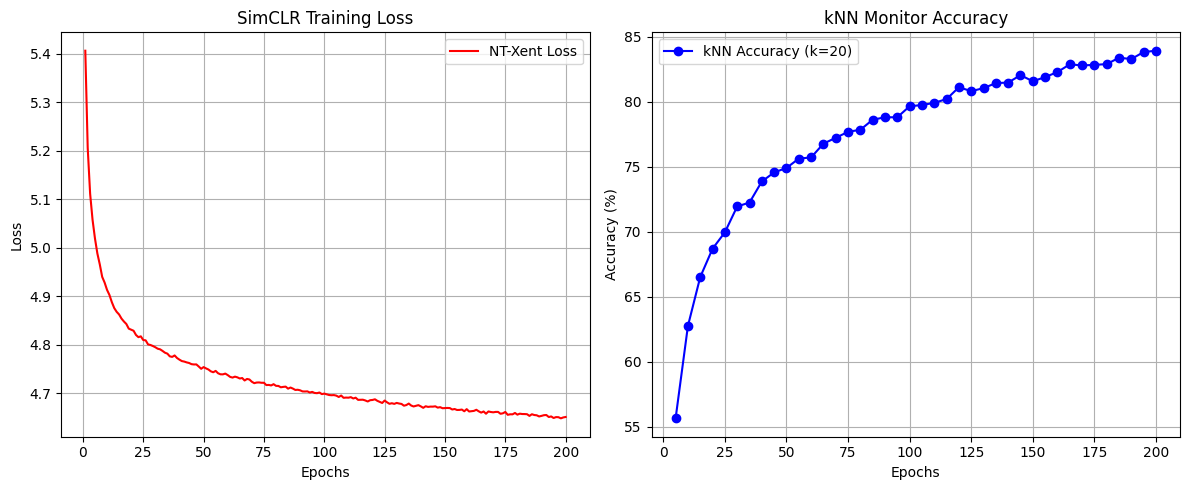

Training complete! Backbone weights saved as 'simclr_backbone.pth'.


In [5]:
# Device Configuration making sure its CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize Model, Loss, and Optimizer
model = SimCLRModel().to(device)
criterion = NTXentLoss(temperature=temperature).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Trackers for final report
loss_history = []
knn_acc_history = []
knn_epochs = []

print("Starting SimCLR Training...")

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0
    
    # tqdm provides a nice progress bar in your notebook
    loop = tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}')
    
    for pos_1, pos_2, _ in loop:
        pos_1, pos_2 = pos_1.to(device), pos_2.to(device)
        
        # Forward pass (we only need 'z' for the loss calculation)
        _, z_i = model(pos_1)
        _, z_j = model(pos_2)
        
        # Calculate NT-Xent Loss
        loss = criterion(z_i, z_j)
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())
        
    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    
    # Run the kNN Monitor every 5 epochs
    if epoch % 5 == 0:
        knn_acc = knn_monitor(model, memory_loader, test_loader, k=k_neighbors)
        knn_acc_history.append(knn_acc)
        knn_epochs.append(epoch)
        print(f"\n--- Epoch {epoch} completed | Avg Loss: {avg_loss:.4f} | kNN Accuracy: {knn_acc:.2f}% ---\n")

# --- PLOTTING FOR THE REPORT ---
plt.figure(figsize=(12, 5))

# Plot 1: Training Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), loss_history, label='NT-Xent Loss', color='red')
plt.title('SimCLR Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Plot 2: kNN Accuracy
plt.subplot(1, 2, 2)
plt.plot(knn_epochs, knn_acc_history, label=f'kNN Accuracy (k={k_neighbors})', color='blue', marker='o')
plt.title('kNN Monitor Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Save the backbone weights for Phase 3 (Linear Probing)
torch.save(model.backbone.state_dict(), 'simclr_backbone.pth')
print("Training complete! Backbone weights saved as 'simclr_backbone.pth'.")

In [ ]:
# save the plot data to a physical file
training_details = {
    "loss_history": loss_history,
    "knn_acc_history": knn_acc_history,
    "knn_epochs": knn_epochs
}

with open('training_history.json', 'w') as f:
    json.dump(training_details, f)

print("Training history securely saved to disk!")

Training history securely saved to disk!


After a good looking feature learning without labels, we formed our backbone. Let's move to linear probing.

In [9]:
class LinearProbe(nn.Module):
    def __init__(self, num_classes=10):
        super(LinearProbe, self).__init__()
        # Load the ResNet-18 structure
        simclr_model = SimCLRModel()
        self.backbone = simclr_model.backbone
        
        # Load your hard SSL weights!
        self.backbone.load_state_dict(torch.load('simclr_backbone.pth'))
        
        # FREEZE THE BACKBONE
        # This tells PyTorch to completely ignore these layers during backpropagation
        for param in self.backbone.parameters():
            param.requires_grad = False
            
        # Attach the new Classification Head (512 -> 10)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        # Pass the image through the frozen backbone
        # torch.no_grad() guarantees no memory is wasted tracking gradients here
        with torch.no_grad():
            features = self.backbone(x)
            
        # Pass the 512-dimension features to our single linear layer
        output = self.fc(features)
        return output

# --- Hyperparameters ---
batch_size = 256
learning_rate = 1e-3 # Requirement
epochs = 100         # Requirement
weight_decay = 1e-6 

# --- Standard Supervised Data Loaders ---
# We just use standard crops/flips and standard labels.
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_data_lp = CIFAR10(root='./data', train=True, transform=train_transform, download=False)
train_loader_lp = DataLoader(train_data_lp, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

test_data_lp = CIFAR10(root='./data', train=False, transform=test_transform, download=False)
test_loader_lp = DataLoader(test_data_lp, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# --- Initialize Setup ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Starting Linear Probing on: {device}")

model_lp = LinearProbe().to(device)

# Standard classification loss
criterion_lp = nn.CrossEntropyLoss()

# CRITICAL: We ONLY give the optimizer the parameters of the new `fc` layer. 
# The frozen backbone weights are kept completely safe from the optimizer.
optimizer_lp = torch.optim.Adam(model_lp.fc.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Tracking metrics
lp_loss_history = []
lp_acc_history = []

for epoch in range(1, epochs + 1):
    model_lp.train()
    total_loss = 0
    correct = 0
    total = 0
    
    loop = tqdm(train_loader_lp, desc=f'Linear Probing Epoch {epoch}/{epochs}')
    
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model_lp(images)
        loss = criterion_lp(outputs, labels)
        
        # Backward pass (only updates the linear layer)
        optimizer_lp.zero_grad()
        loss.backward()
        optimizer_lp.step()
        
        total_loss += loss.item()
        
        # Calculate training accuracy for this batch
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)
        
    lp_loss_history.append(total_loss / len(train_loader_lp))
    
    # --- Quick Evaluation on Test Set Every 10 Epochs ---
    if epoch % 10 == 0 or epoch == epochs:
        model_lp.eval()
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for test_images, test_labels in test_loader_lp:
                test_images, test_labels = test_images.to(device), test_labels.to(device)
                outputs = model_lp(test_images)
                _, predicted = outputs.max(1)
                test_total += test_labels.size(0)
                test_correct += predicted.eq(test_labels).sum().item()
        
        test_acc = 100. * test_correct / test_total
        lp_acc_history.append(test_acc)
        print(f"\n--- Epoch {epoch} Test Accuracy: {test_acc:.2f}% ---\n")

print(f"Final Linear Probing Accuracy: {lp_acc_history[-1]:.2f}%")

Starting Linear Probing on: cuda


Linear Probing Epoch 10/100: 100%|██████████| 196/196 [00:19<00:00,  9.92it/s, acc=82.8, loss=0.496]



--- Epoch 10 Test Accuracy: 82.92% ---



Linear Probing Epoch 20/100: 100%|██████████| 196/196 [00:19<00:00,  9.84it/s, acc=83.5, loss=0.581]



--- Epoch 20 Test Accuracy: 83.54% ---



...


--- Epoch 80 Test Accuracy: 84.07% ---



Linear Probing Epoch 90/100: 100%|██████████| 196/196 [00:20<00:00,  9.49it/s, acc=84.8, loss=0.353]



--- Epoch 90 Test Accuracy: 83.97% ---



Linear Probing Epoch 100/100: 100%|██████████| 196/196 [00:20<00:00,  9.49it/s, acc=84.7, loss=0.254]



--- Epoch 100 Test Accuracy: 83.84% ---

Final Linear Probing Accuracy: 83.84%


In [ ]:
print("\n=== Linear Probing Training Summary ===")
# lp_acc_history was recorded every 10 epochs
for i, acc in enumerate(lp_acc_history):
    epoch_num = (i + 1) * 10
    print(f"Epoch {epoch_num:3d} | Test Accuracy: {acc:.2f}%")

print(f"\nFinal Average Loss (Epoch 100): {lp_loss_history[-1]:.4f}")
print("=======================================")


# Save the Linear Probing Model Weights
# (This saves the frozen backbone + the trained linear layer)
torch.save(model_lp.state_dict(), 'linear_probe_model.pth')

# Save the Training History for your Report Graphs
test_epochs = [i for i in range(10, epochs + 1, 10)] 
lp_training_details = {
    "loss_history": lp_loss_history,
    "test_acc_history": lp_acc_history,
    "test_epochs": test_epochs
}

with open('lp_training_history.json', 'w') as f:
    json.dump(lp_training_details, f)

print("Linear Probing model and history successfully saved to disk!")


=== Linear Probing Training Summary ===
Epoch  10 | Test Accuracy: 82.92%
Epoch  20 | Test Accuracy: 83.54%
Epoch  30 | Test Accuracy: 83.69%
Epoch  40 | Test Accuracy: 83.71%
Epoch  50 | Test Accuracy: 83.81%
Epoch  60 | Test Accuracy: 84.03%
Epoch  70 | Test Accuracy: 84.09%
Epoch  80 | Test Accuracy: 84.07%
Epoch  90 | Test Accuracy: 83.97%
Epoch 100 | Test Accuracy: 83.84%

Final Average Loss (Epoch 100): 0.4305
Linear Probing model and history successfully saved to disk!


I still have leftover variables on my GPU VRAM from previous trainings and will cause my next step to not fit in desired GPU memory. I want to flush this memory without deleting the variables and outputs so far from RAM (without doing Kernel restart):

In [12]:
import gc
import torch

# Delete the heavy variables from Phase 3 to remove them from Python's memory
try:
    del model_lp
    del optimizer_lp
    del outputs
    del loss
except NameError:
    pass # If they are already gone, just ignore

# Force Python's Garbage Collector to clean up the deleted variables
gc.collect()

# Force PyTorch to empty the actual GPU VRAM cache
torch.cuda.empty_cache()

# Check how much memory is still being used
allocated_memory = torch.cuda.memory_allocated() / (1024 ** 2)
print(f"GPU memory successfully flushed!")
print(f"Current VRAM allocated: {allocated_memory:.2f} MB")

GPU memory successfully flushed!
Current VRAM allocated: 201.51 MB


Now, for comparison purposes, let's do traditional way of ResNet-18 as Supervised Learning (attaching classification layer at the end rightaway):

Starting Supervised Baseline Training on: cuda


SL Baseline Epoch 10/100: 100%|██████████| 196/196 [00:46<00:00,  4.22it/s, acc=89.2, loss=0.197]



--- Epoch 10 SL Test Accuracy: 85.07% ---



SL Baseline Epoch 20/100: 100%|██████████| 196/196 [00:44<00:00,  4.37it/s, acc=94.7, loss=0.151] 



--- Epoch 20 SL Test Accuracy: 88.33% ---



...


--- Epoch 80 SL Test Accuracy: 91.39% ---



SL Baseline Epoch 90/100: 100%|██████████| 196/196 [00:44<00:00,  4.38it/s, acc=99.2, loss=0.0171] 



--- Epoch 90 SL Test Accuracy: 91.78% ---



SL Baseline Epoch 100/100: 100%|██████████| 196/196 [00:44<00:00,  4.37it/s, acc=99.3, loss=0.0416] 



--- Epoch 100 SL Test Accuracy: 92.23% ---

Final Supervised Baseline Accuracy: 92.23%

Generating Supervised Baseline Plots...


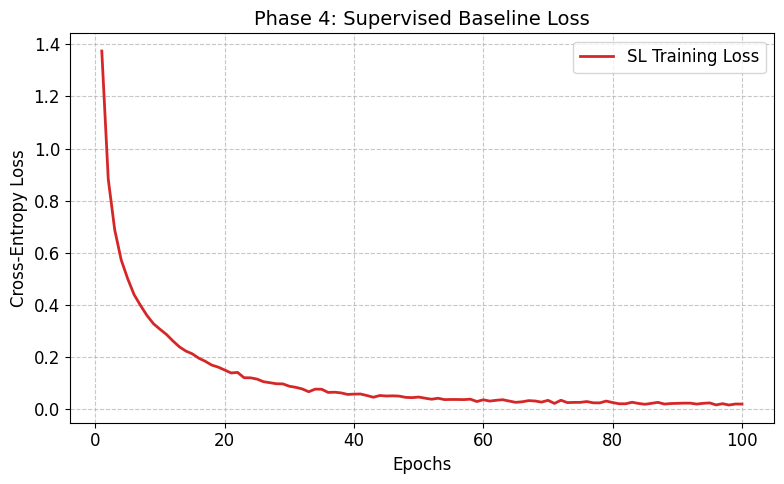

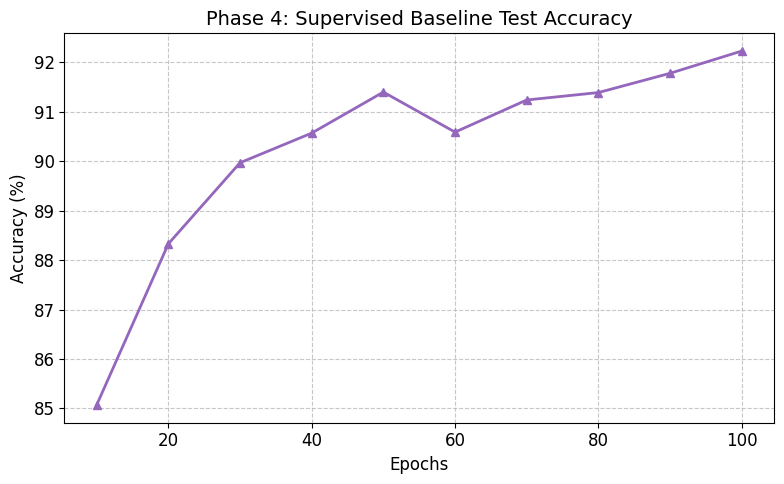

Supervised baseline successfully saved to disk!


In [13]:
class SupervisedBaseline(nn.Module):
    def __init__(self, num_classes=10):
        super(SupervisedBaseline, self).__init__()
        # Load a FRESH ResNet-18 structure
        simclr_model = SimCLRModel()
        self.backbone = simclr_model.backbone
        
        # NOTE: We are NOT loading the simclr_backbone.pth weights here!
        # This backbone is completely random, blank slate.
        
        # Attach the new Classification Head (512 -> 10)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        # Pass the image through the backbone
        features = self.backbone(x)
        # Pass the features to our linear layer
        output = self.fc(features)
        return output

# --- Phase 4 Hyperparameters ---
batch_size = 256
learning_rate = 1e-3
weight_decay = 1e-6 
epochs = 100         

# --- Standard Supervised Data Loaders ---
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_data_sl = CIFAR10(root='./data', train=True, transform=train_transform, download=False)
train_loader_sl = DataLoader(train_data_sl, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

test_data_sl = CIFAR10(root='./data', train=False, transform=test_transform, download=False)
test_loader_sl = DataLoader(test_data_sl, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# --- Initialize Setup ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Starting Supervised Baseline Training on: {device}")

model_sl = SupervisedBaseline().to(device)
criterion_sl = nn.CrossEntropyLoss()

# CRITICAL DIFFERENCE: We give the optimizer ALL parameters (backbone + fc layer)
optimizer_sl = torch.optim.Adam(model_sl.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Tracking metrics
sl_loss_history = []
sl_acc_history = []

# --- Supervised Training Loop ---
for epoch in range(1, epochs + 1):
    model_sl.train()
    total_loss = 0
    correct = 0
    total = 0
    
    loop = tqdm(train_loader_sl, desc=f'SL Baseline Epoch {epoch}/{epochs}')
    
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model_sl(images)
        loss = criterion_sl(outputs, labels)
        
        # Backward pass (updates the ENTIRE network)
        optimizer_sl.zero_grad()
        loss.backward()
        optimizer_sl.step()
        
        total_loss += loss.item()
        
        # Calculate training accuracy
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)
        
    sl_loss_history.append(total_loss / len(train_loader_sl))
    
    # --- Test Set Evaluation ---
    if epoch % 10 == 0 or epoch == epochs:
        model_sl.eval()
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for test_images, test_labels in test_loader_sl:
                test_images, test_labels = test_images.to(device), test_labels.to(device)
                outputs = model_sl(test_images)
                _, predicted = outputs.max(1)
                test_total += test_labels.size(0)
                test_correct += predicted.eq(test_labels).sum().item()
        
        test_acc = 100. * test_correct / test_total
        sl_acc_history.append(test_acc)
        print(f"\n--- Epoch {epoch} SL Test Accuracy: {test_acc:.2f}% ---\n")

print(f"Final Supervised Baseline Accuracy: {sl_acc_history[-1]:.2f}%")

print("\nGenerating Supervised Baseline Plots...")

# For the report
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14})

# Plot the Supervised Training Loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), sl_loss_history, label='SL Training Loss', color='#d62728', linewidth=2)
plt.title('Phase 4: Supervised Baseline Loss')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('report_fig4_sl_loss.png', dpi=300)
plt.show()

# Plot the Supervised Test Accuracy
# We know test accuracy was recorded every 10 epochs
test_epochs_sl = [i for i in range(10, epochs + 1, 10)] 

plt.figure(figsize=(8, 5))
plt.plot(test_epochs_sl, sl_acc_history, marker='^', color='#9467bd', linewidth=2)
plt.title('Phase 4: Supervised Baseline Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('report_fig5_sl_accuracy.png', dpi=300)
plt.show()


# Save the model and history
torch.save(model_sl.state_dict(), 'supervised_baseline.pth')
with open('sl_training_history.json', 'w') as f:
    json.dump({"loss": sl_loss_history, "acc": sl_acc_history}, f)
print("Supervised baseline successfully saved to disk!")